In [16]:
import pandas as pd

# Load datasets
employees = pd.read_csv("employees.csv")
attrition = pd.read_csv("attrition_log.csv")
engagement = pd.read_csv("engagement.csv")
performance = pd.read_csv("performance.csv")

# Combine all datasets using employee_id
df = employees.merge(
    engagement,
    on="employee_id",
    how="left"
)

df = df.merge(
    performance,
    on="employee_id",
    how="left"
)

df = df.merge(
    attrition,
    on="employee_id",
    how="left"
)

# Display all columns
pd.set_option("display.max_columns", None)

print("Shape:", combined.shape)

df.head()

Shape: (160196, 50)


,employee_id,name,hire_date,exit_date_x,status,department,role_family,role_level,job_title,salary,compa_ratio,gender,age_band,cultural_background,contract_type,hipo_flag,promotion_eligible,manager_id,hire_source,legacy_entity_code,data_source_system,days_to_fill,tenure_months,acting_appointment,wave_number,survey_date,response_flag,manager_effectiveness,psychological_safety,recognition,career_development,senior_leadership_trust,purpose_meaning,wellbeing,confidence_in_role_future,review_date,performance_rating,review_cycle,promotion_recommendation,goal_achievement_score,reviewer_id,exit_date_y,exit_type,stated_exit_reason,notice_period_served,regrettable_flag,performance_band_at_exit,salary_at_exit,manager_id_at_exit,pathway
0,E00001,Madison Lang,1988-01-11,NaN,active,Wealth Management,Operations-Processing,2,"Manager, Wealth Management",115200.0,0.79,Female,60+,Anglo-Australian,Full-time,False,False,E04330,referral,NovaCorp-Origin,WorkdayHR,22.0,462,False,1.0,2024-03-08,True,5.00,4.39,4.55,4.25,3.72,3.47,4.83,4.57,2024-06-01,Meets Expectations,2024-H1,False,46.1,E04330,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,E00001,Madison Lang,1988-01-11,NaN,active,Wealth Management,Operations-Processing,2,"Manager, Wealth Management",115200.0,0.79,Female,60+,Anglo-Australian,Full-time,False,False,E04330,referral,NovaCorp-Origin,WorkdayHR,22.0,462,False,1.0,2024-03-08,True,5.00,4.39,4.55,4.25,3.72,3.47,4.83,4.57,2024-11-21,Meets Expectations,2024-H2,False,65.4,E04330,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,E00001,Madison Lang,1988-01-11,NaN,active,Wealth Management,Operations-Processing,2,"Manager, Wealth Management",115200.0,0.79,Female,60+,Anglo-Australian,Full-time,False,False,E04330,referral,NovaCorp-Origin,WorkdayHR,22.0,462,False,1.0,2024-03-08,True,5.00,4.39,4.55,4.25,3.72,3.47,4.83,4.57,2025-05-28,Meets Expectations,2025-H1,False,76.4,E04330,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,E00001,Madison Lang,1988-01-11,NaN,active,Wealth Management,Operations-Processing,2,"Manager, Wealth Management",115200.0,0.79,Female,60+,Anglo-Australian,Full-time,False,False,E04330,referral,NovaCorp-Origin,WorkdayHR,22.0,462,False,2.0,2024-06-27,True,4.69,4.26,4.10,3.52,3.57,4.00,4.79,4.71,2024-06-01,Meets Expectations,2024-H1,False,46.1,E04330,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,E00001,Madison Lang,1988-01-11,NaN,active,Wealth Management,Operations-Processing,2,"Manager, Wealth Management",115200.0,0.79,Female,60+,Anglo-Australian,Full-time,False,False,E04330,referral,NovaCorp-Origin,WorkdayHR,22.0,462,False,2.0,2024-06-27,True,4.69,4.26,4.10,3.52,3.57,4.00,4.79,4.71,2024-11-21,Meets Expectations,2024-H2,False,65.4,E04330,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# PART 1 — EMPLOYEE POPULATION PROFILE

print("EMPLOYEE POPULATION")
print("=" * 60)

print(f"Total employees: {len(df):,}")
print(f"Departments: {df['department'].nunique()}")
print(f"Role families: {df['role_family'].nunique()}")
print(f"Job titles: {df['job_title'].nunique()}")


# Department size

department_size = (
    df["department"]
    .value_counts()
    .rename_axis("department")
    .reset_index(name="employees")
)

department_size["percentage"] = (
    department_size["employees"]
    / len(df) * 100
)

display(department_size)


# Role family size

role_family_size = (
    df["role_family"]
    .value_counts()
    .rename_axis("role_family")
    .reset_index(name="employees")
)

role_family_size["percentage"] = (
    role_family_size["employees"]
    / len(df) * 100
)

display(role_family_size)

EMPLOYEE POPULATION
Total employees: 160,196
Departments: 7
Role families: 7
Job titles: 65


,department,employees,percentage
0,Retail Banking,39318,24.543684
1,Technology,36529,22.802692
2,Risk & Compliance,24154,15.077780
3,Insurance,21297,13.294339
4,Wealth Management,18371,11.467827
5,Corporate Operations,17858,11.147594
6,Executive Leadership,2669,1.666084


,role_family,employees,percentage
0,Operations-Processing,34606,21.602287
1,Client-Advisory,28308,17.670853
2,Technology,27095,16.913656
3,Corporate-Support,24638,15.379910
4,Risk-Compliance,23107,14.424205
5,Management,22122,13.809334
6,Executive,320,0.199755


role_family,Client-Advisory,Corporate-Support,Executive,Management,Operations-Processing,Risk-Compliance,Technology
department,,,,,,,
Corporate Operations,17.2,14.7,0.1,13.3,22.4,14.4,17.9
Executive Leadership,16.9,13.8,6.7,14.2,18.0,14.9,15.5
Insurance,17.2,16.0,0.1,15.2,20.9,14.4,16.1
Retail Banking,18.2,14.7,0.1,12.9,21.7,15.2,17.3
Risk & Compliance,18.8,16.7,0.1,13.0,20.7,15.0,15.6
Technology,17.1,15.7,0.1,14.0,23.2,13.0,17.0
Wealth Management,17.2,14.7,0.1,15.3,20.0,14.8,17.8


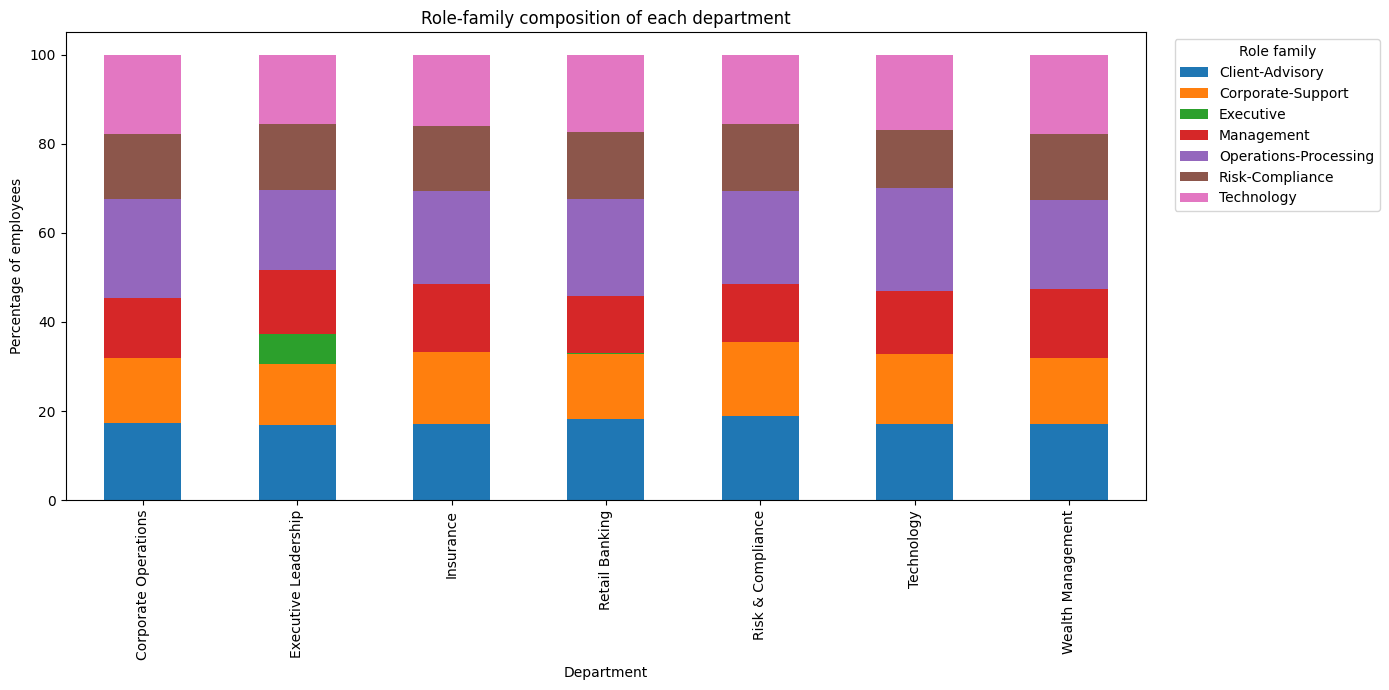

In [ ]:
# 2. DEPARTMENT COMPOSITION

department_composition = pd.crosstab(
    df["department"],
    df["role_family"],
    normalize="index"
) * 100

display(department_composition.round(1))

department_composition.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

plt.title("Role-family composition of each department")
plt.xlabel("Department")
plt.ylabel("Percentage of employees")
plt.legend(
    title="Role family",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [24]:
department_analysis = (
    df.groupby("department")
      .agg(
          employees=("employee_id", "nunique"),
          leavers=("exit_type", lambda x: x.notna().sum()),
          median_salary=("salary", "median"),
          mean_salary=("salary", "mean")
      )
)

department_analysis["attrition_rate"] = (
    department_analysis["leavers"]
    / department_analysis["employees"]
    * 100
)

department_analysis = department_analysis.sort_values(
    "attrition_rate",
    ascending=False
)

display(department_analysis.round(2))

,employees,leavers,median_salary,mean_salary,attrition_rate
department,,,,,
Risk & Compliance,2022,1260,123000.0,129117.15,62.31
Corporate Operations,1509,939,123900.0,128911.57,62.23
Wealth Management,1549,877,122400.0,128974.21,56.62
Insurance,1781,984,124300.0,129110.03,55.25
Technology,3032,1668,123900.0,128704.36,55.01
Retail Banking,3280,1597,122600.0,127754.18,48.69
Executive Leadership,230,83,127100.0,169954.63,36.09


In [26]:
# Merge department information onto attrition records

leavers = attrition.merge(
    employees[["employee_id", "department"]],
    on="employee_id",
    how="left"
)

display(leavers.head())

,employee_id,exit_date,exit_type,stated_exit_reason,notice_period_served,regrettable_flag,performance_band_at_exit,salary_at_exit,manager_id_at_exit,pathway,department
0,E00005,2024-12-24,voluntary,Relocation,True,False,Meets Expectations,132400.0,E12337,push,Wealth Management
1,E00006,2025-04-17,voluntary,Work-life balance,True,False,Below Expectations,120600.0,E00218,push,Corporate Operations
2,E00008,2024-02-19,voluntary,Career advancement,True,False,Meets Expectations,117800.0,E00249,push,Technology
3,E00021,2024-05-24,voluntary,Career advancement,True,False,Meets Expectations,125500.0,E08861,push,Insurance
4,E00023,2025-07-04,voluntary,Career advancement,False,False,Outstanding,175400.0,E09824,pull,Technology


,department,leavers,median_exit_salary,mean_exit_salary
0,Technology,315,120600.0,120314.92
1,Retail Banking,306,122450.0,124807.52
2,Risk & Compliance,239,125600.0,129519.25
3,Insurance,184,123050.0,127102.72
4,Corporate Operations,175,124800.0,125908.00
5,Wealth Management,162,123700.0,128820.99
6,Executive Leadership,19,129300.0,128763.16


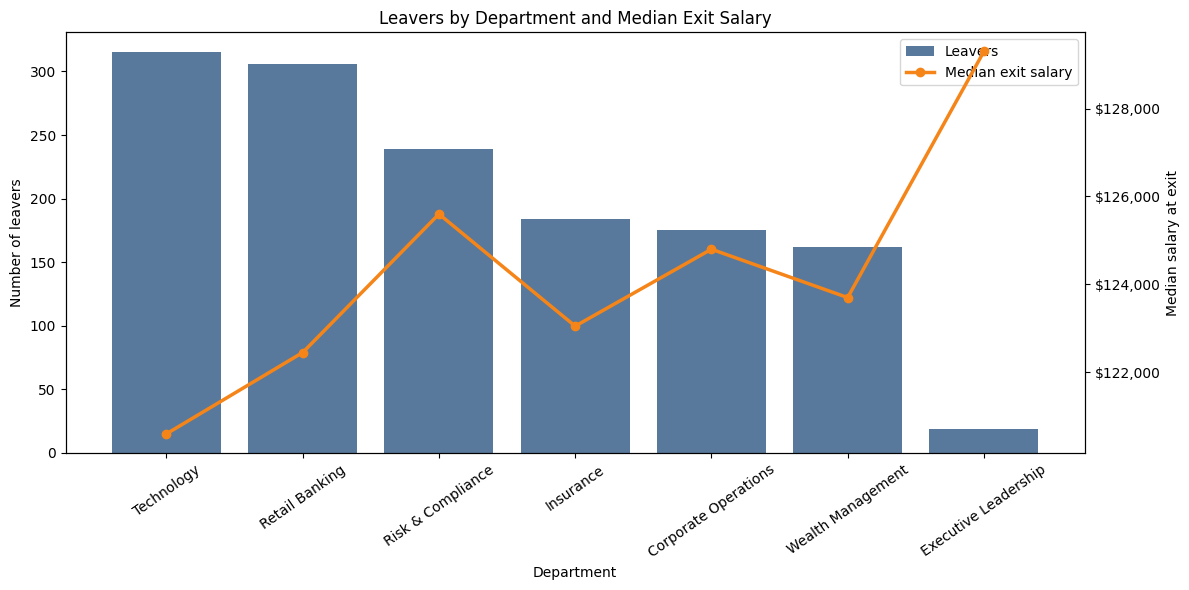

In [27]:

# 4. LEAVERS BY DEPARTMENT + EXIT SALARY

leavers_by_department = (
    leavers.groupby("department")
    .agg(
        leavers=("employee_id", "nunique"),
        median_exit_salary=("salary_at_exit", "median"),
        mean_exit_salary=("salary_at_exit", "mean")
    )
    .sort_values("leavers", ascending=False)
    .reset_index()
)

display(leavers_by_department.round(2))

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=leavers_by_department,
    x="department",
    y="leavers",
    ax=ax1,
    color="#4C78A8",
    label="Leavers"
)

ax1.set_title("Leavers by Department and Median Exit Salary")
ax1.set_xlabel("Department")
ax1.set_ylabel("Number of leavers")
ax1.tick_params(axis="x", rotation=35)

ax2 = ax1.twinx()
ax2.plot(
    leavers_by_department["department"],
    leavers_by_department["median_exit_salary"],
    color="#F58518",
    marker="o",
    linewidth=2.5,
    label="Median exit salary"
)
ax2.set_ylabel("Median salary at exit")
ax2.yaxis.set_major_formatter(lambda x, _: f"${x:,.0f}")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()



In [31]:
# ------------------------------------------------------------
# 5. ATTRITION BY HIRE SOURCE
# ------------------------------------------------------------

attrition_hire_source_detail = (
    leavers[["employee_id", "hire_source", "department", "exit_type", "salary_at_exit"]]
    .sort_values(["hire_source", "employee_id"])
    .reset_index(drop=True)
)

print("First 20 leavers matched back to their hire source:")
display(attrition_hire_source_detail.head(20))

hire_source_summary = (
    df.groupby("hire_source")
    .agg(
        total_employees=("employee_id", "nunique"),
        leavers=("exit_type", lambda x: x.notna().sum())
    )
    .reset_index()
)

hire_source_summary["attrition_rate"] = (
    hire_source_summary["leavers"]
    / hire_source_summary["total_employees"]
    * 100
)

hire_source_summary = hire_source_summary.sort_values(
    "attrition_rate",
    ascending=False
)

display(hire_source_summary.round(2))

fig, ax1 = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=hire_source_summary,
    x="hire_source",
    y="leavers",
    ax=ax1,
    color="#72B7B2",
    label="Leavers"
)

ax1.set_title("Attrition by Hire Source")
ax1.set_xlabel("Hire source")
ax1.set_ylabel("Number of leavers")

ax2 = ax1.twinx()
ax2.plot(
    hire_source_summary["hire_source"],
    hire_source_summary["attrition_rate"],
    color="#E45756",
    marker="o",
    linewidth=2.5,
    label="Attrition rate"
)
ax2.set_ylabel("Attrition rate")
ax2.yaxis.set_major_formatter(lambda x, _: f"{x:.1f}%")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()


KeyError: "['hire_source'] not in index"